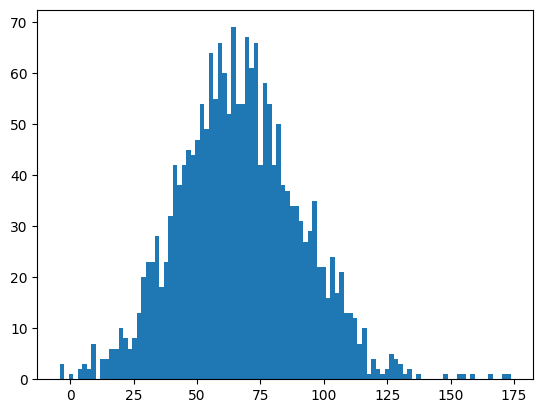

In [15]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(123)
m = 2000

experiences = rng.exponential(scale=4, size=(m, 1))
education = rng.normal(7, 4, size=(m, 1))

TRUE_BIAS = 20.0
TRUE_W_EXP = 3.0
TRUE_W_EDU = 5.0

salaries = (TRUE_BIAS + 
            TRUE_W_EXP * experiences + 
            TRUE_W_EDU * education + 
            rng.normal(0, 5, size=(m, 1)))

plt.hist(salaries, bins=100)
plt.show()

In [16]:
from sklearn.preprocessing import add_dummy_feature

X = np.hstack([experiences / 10, education / 10])
X_dummy = add_dummy_feature(X)

y = salaries / 10

X_dummy, y

(array([[1.        , 0.238789  , 0.66774206],
        [1.        , 0.04681242, 1.0110066 ],
        [1.        , 0.10071788, 0.93592318],
        ...,
        [1.        , 1.63372722, 0.71608266],
        [1.        , 0.03350721, 0.86319078],
        [1.        , 0.28983801, 0.83907169]], shape=(2000, 3)),
 array([[ 5.07146875],
        [ 6.61132393],
        [ 7.06058317],
        ...,
        [10.41154676],
        [ 5.84496454],
        [ 7.50390909]], shape=(2000, 1)))

In [17]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0]

array([0.238789  , 0.66774206])

In [18]:
print(X[0] ** 2)
print(X[0, 0] * X[0, 1])

[0.05702019 0.44587946]
0.15944945710107533


In [19]:
X_poly[0]

array([0.238789  , 0.66774206, 0.05702019, 0.15944946, 0.44587946])

In [20]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.99667953]),
 array([[ 3.0481463 ,  5.00260298, -0.03147609,  0.03146193, -0.01163584]]))

In [21]:
from sklearn.pipeline import Pipeline

full_pipeline = Pipeline([
    ("poly_features", PolynomialFeatures(degree=2, include_bias=False)),
    ("lin_reg", LinearRegression())
])

full_pipeline.fit(X, y)
full_pipeline["lin_reg"].intercept_, full_pipeline["lin_reg"].coef_

(array([1.99667953]),
 array([[ 3.0481463 ,  5.00260298, -0.03147609,  0.03146193, -0.01163584]]))

In [31]:
# single prediction — 8 years experience
X_test = np.array([[8 / 10, 10 / 10]])  
pred = full_pipeline.predict(X_test) * 10  

print(f"Predicted salary (8yr exp): ${pred[0, 0]:.1f}k")

Predicted salary (8yr exp): $94.3k
